### Experiment for testing better feature vector size for the classifiers

In [1]:
# imports
import matplotlib.pyplot as plt
from dataset_utils import *
from pipeline_utils.ClassificationHeads import BaselineClassificationHead
from sklearn.preprocessing import RobustScaler
import umap
from transformers import DistilBertTokenizer, AutoModel
import numpy as np
import torch
from pipeline_utils.pipeline_utils import create_profile_vector, create_tweet_vectors, train_classifier, test_classifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix

/home/max/ProgrammingProjects/-Social-Media-Bot-Detection-with-Continuous-Learning/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# umap sizes to test
dim_sizes = [768, 576, 384, 192, 77, 38, 16] # 100%, 75%, 50%, 25%, 10%, 5%, 2%

device = 'cuda' if torch.cuda.is_available() else 'cpu'
# training and testing on reduced feature vector size (ie. was passed through UMAP)
def calculate_raw_feature_vectors(data_loader, device ='cuda' if torch.cuda.is_available() else 'cpu'):
    # -- initial setup
    tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
    model = AutoModel.from_pretrained("distilbert-base-uncased").to(device)
    model = torch.compile(model)
    scaler = RobustScaler(with_centering=False)

    # -- training loop
    ground_truth_labels = []
    profile_vectors = []
    tweet_vectors = []
    for i, sample in enumerate(data_loader):
        # get feature vectors
        profile_embed = create_profile_vector(sample.user_data)
        tweet_embeds = create_tweet_vectors(sample.tweet_data, tokenizer, model, max_tweets= 300, batch_size = 300)
        # pool tweet vectors
        tweet_vec = torch.mean(tweet_embeds, dim=0, dtype=torch.float32)

        # append feature vectors and ground truth
        profile_vectors.append(profile_embed)
        tweet_vectors.append(tweet_vec)
        ground_truth_labels.append(sample.label)
        print(f"\rIteration: {i} | {sample.label}", end="")
    # scale profile vectors
    scaled_profile_vectors = scaler.fit_transform(profile_vectors)

    return tweet_vectors, scaled_profile_vectors, ground_truth_labels

def experiment_on_dim_sizes(training_data, validation_data, class_amount, dim_sizes = [768, 576, 384, 192, 77, 38, 16]):
     # process data to vectors (do it once as this part stays the same between runs and is compute intensive)
    train_tweet_vectors, train_profile_vectors, train_ground_truth_labels = calculate_raw_feature_vectors(training_data)
    val_tweet_vectors, val_profile_vectors, val_ground_truth_labels = calculate_raw_feature_vectors(validation_data)

    for dim_size in dim_sizes:
        dim_reducer = umap.UMAP(n_components=dim_size, n_neighbors=20, min_dist=0.1, metric="cosine", target_metric="categorical", target_weight=0.25)
        classifier = BaselineClassificationHead(dim_size+7,class_amount).to(device)
        print("[] --- experiment results for dim: " + str(dim_size) + " --- []")
        ## training

        # create final embeddings (dim reduction & concat)
        train_reduced_tweet_vectors = dim_reducer.fit_transform(X=train_tweet_vectors, y=torch.tensor(train_ground_truth_labels))
        train_reduced_tweet_vectors = np.nan_to_num(train_reduced_tweet_vectors, nan=0.0, posinf=0.0, neginf=0.0)
        train_embedding_features = [np.concatenate((t1, t2), axis=0) for t1, t2 in zip(train_reduced_tweet_vectors, train_profile_vectors)]

        # perform classification training
        criterion = torch.nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(classifier.parameters(), lr=0.01)
        ground_truths, predictions = train_classifier(classifier, criterion, optimizer, train_embedding_features, train_ground_truth_labels)
        print("[ -- training results -- ]")
        print("accuracy: ", accuracy_score(ground_truths, predictions))
        print("recall: ", recall_score(ground_truths, predictions, average="macro"))
        print("f1 score: ", f1_score(ground_truths, predictions, average="macro"))
        print(confusion_matrix(ground_truths, predictions))

        ## testing (on validation split)

        # create final embeddings (dim reduction & concat)
        val_reduced_tweet_vectors = dim_reducer.transform(X=val_tweet_vectors)
        val_reduced_tweet_vectors = np.nan_to_num(val_reduced_tweet_vectors, nan=0.0, posinf=0.0, neginf=0.0)
        val_embedding_features = [np.concatenate((t1, t2), axis=0) for t1, t2 in zip(val_reduced_tweet_vectors, val_profile_vectors)]
        # perform testing
        ground_truths, predictions = test_classifier(classifier, val_embedding_features, val_ground_truth_labels)
        print("[ -- validation results -- ]")
        print("accuracy: ", accuracy_score(ground_truths, predictions))
        print("recall: ", recall_score(ground_truths, predictions, average="macro"))
        print("f1 score: ", f1_score(ground_truths, predictions, average="macro"))
        print(confusion_matrix(ground_truths, predictions))

In [3]:
# Dataset: Cresci 17

# datasets
dataset_mode = "train"
user_dataset = Cresci17(Cresci17SetTypes.GENUINE_USER, dataset_mode, root="../datasets", custom_label=0)
fake_dataset = Cresci17(Cresci17SetTypes.FAKE_FOLLOWER, dataset_mode, root="../datasets", custom_label=1)
social1_dataset = Cresci17(Cresci17SetTypes.SOCIAL_SPAM_1, dataset_mode, root="../datasets", custom_label=2)
social2_dataset = Cresci17(Cresci17SetTypes.SOCIAL_SPAM_2, dataset_mode, root="../datasets", custom_label=2)
social3_dataset = Cresci17(Cresci17SetTypes.SOCIAL_SPAM_3, dataset_mode, root="../datasets", custom_label=2)
traditional1_dataset = Cresci17(Cresci17SetTypes.TRADITIONAL_SPAM_1, dataset_mode, root="../datasets", custom_label=3)
traditional2_dataset = Cresci17(Cresci17SetTypes.TRADITIONAL_SPAM_2, dataset_mode, root="../datasets", custom_label=3)
traditional3_dataset = Cresci17(Cresci17SetTypes.TRADITIONAL_SPAM_3, dataset_mode, root="../datasets", custom_label=3)
traditional4_dataset = Cresci17(Cresci17SetTypes.TRADITIONAL_SPAM_4, dataset_mode, root="../datasets", custom_label=3)
combo_train_dataset = InterleavedIterableDataset([user_dataset, fake_dataset, social1_dataset, social2_dataset, social3_dataset,
        traditional1_dataset, traditional2_dataset, traditional3_dataset, traditional4_dataset], "Random")

dataset_mode = "dev"
user_dataset = Cresci17(Cresci17SetTypes.GENUINE_USER, dataset_mode, root="../datasets", custom_label=0)
fake_dataset = Cresci17(Cresci17SetTypes.FAKE_FOLLOWER, dataset_mode, root="../datasets", custom_label=1)
social1_dataset = Cresci17(Cresci17SetTypes.SOCIAL_SPAM_1, dataset_mode, root="../datasets", custom_label=2)
social2_dataset = Cresci17(Cresci17SetTypes.SOCIAL_SPAM_2, dataset_mode, root="../datasets", custom_label=2)
social3_dataset = Cresci17(Cresci17SetTypes.SOCIAL_SPAM_3, dataset_mode, root="../datasets", custom_label=2)
traditional1_dataset = Cresci17(Cresci17SetTypes.TRADITIONAL_SPAM_1, dataset_mode, root="../datasets", custom_label=3)
traditional2_dataset = Cresci17(Cresci17SetTypes.TRADITIONAL_SPAM_2, dataset_mode, root="../datasets", custom_label=3)
traditional3_dataset = Cresci17(Cresci17SetTypes.TRADITIONAL_SPAM_3, dataset_mode, root="../datasets", custom_label=3)
traditional4_dataset = Cresci17(Cresci17SetTypes.TRADITIONAL_SPAM_4, dataset_mode, root="../datasets", custom_label=3)
combo_validation_dataset = InterleavedIterableDataset([user_dataset, fake_dataset, social1_dataset, social2_dataset, social3_dataset,
        traditional1_dataset, traditional2_dataset, traditional3_dataset, traditional4_dataset], "Random")

experiment_on_dim_sizes(combo_train_dataset, combo_validation_dataset, 4)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 7276.09it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Iteration: 1 | 3

W0705 12:22:55.583000 24756 .venv/lib/python3.14/site-packages/torch/_inductor/utils.py:1717] [0/0] Not enough SMs to use max_autotune_gemm mode


Iteration: 10144 | 2

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 8988.69it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Iteration: 1238 | 2[] --- experiment results for dim: 768 --- []
Epoch [1/15] - Loss: 3.1747
Epoch [2/15] - Loss: 0.9374
Epoch [3/15] - Loss: 0.8858
Epoch [4/15] - Loss: 0.8759
Epoch [5/15] - Loss: 0.8942
Epoch [6/15] - Loss: 0.8427
Epoch [7/15] - Loss: 0.8253
Epoch [8/15] - Loss: 0.7754
Epoch [9/15] - Loss: 0.7293
Epoch [10/15] - Loss: 0.6964
Epoch [11/15] - Loss: 0.7388
Epoch [12/15] - Loss: 0.6720
Epoch [13/15] - Loss: 0.6653
Epoch [14/15] - Loss: 0.6504
Epoch [15/15] - Loss: 0.6516
Loaded best model weights (Best Loss: 0.6504)
[ -- training results -- ]
accuracy:  0.7293247905372104
recall:  0.6958209510681818
f1 score:  0.6902054068666196
[[2276   84    8  195]
 [  73 1371  337  567]
 [  18  170 2981   24]
 [ 401  718  151  771]]
[ -- validation results -- ]
accuracy:  0.7998385794995965
recall:  0.7528561976497442
f1 score:  0.7039437104254905
[[287   3   0   2]
 [  3 313   4   2]
 [  2   6 372   0]
 [ 14 209   3  19]]
[] --- experiment results for dim: 576 --- []
Epoch [1/15] - 

In [4]:
# Dataset: Cresci 18:
train_dataset = Cresci18("train", root="../datasets", use_only_labelled=True, label_mapping=[1,0,"unlabelled"])
validation_dataset = Cresci18("dev", root="../datasets", use_only_labelled=True, label_mapping=[1,0,"unlabelled"])

experiment_on_dim_sizes(train_dataset, validation_dataset, 2)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 8404.91it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Iteration: 20834 | 0

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 8573.98it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Iteration: 2558 | 1[] --- experiment results for dim: 768 --- []
Epoch [1/15] - Loss: 1.3520
Epoch [2/15] - Loss: 0.6075
Epoch [3/15] - Loss: 0.6007
Epoch [4/15] - Loss: 0.6055
Epoch [5/15] - Loss: 0.6191
Epoch [6/15] - Loss: 0.6008
Epoch [7/15] - Loss: 0.6065
Epoch [8/15] - Loss: 0.6007
-- stopping early --
Loaded best model weights (Best Loss: 0.6007)
[ -- training results -- ]
accuracy:  0.7118310535157187
recall:  0.5
f1 score:  0.41583020243369034
[[    0  6004]
 [    0 14831]]
[ -- validation results -- ]
accuracy:  0.7096522078937085
recall:  0.5
f1 score:  0.4150857142857143
[[   0  743]
 [   0 1816]]
[] --- experiment results for dim: 576 --- []
Epoch [1/15] - Loss: 0.9829
Epoch [2/15] - Loss: 0.4506
Epoch [3/15] - Loss: 0.4357
Epoch [4/15] - Loss: 0.4250
Epoch [5/15] - Loss: 0.4110
Epoch [6/15] - Loss: 0.4166
Epoch [7/15] - Loss: 0.4364
Epoch [8/15] - Loss: 0.4092
Epoch [9/15] - Loss: 0.4184
Epoch [10/15] - Loss: 0.4024
Epoch [11/15] - Loss: 0.4074
Epoch [12/15] - Loss: 0.402

In [5]:
# Dataset: Caverlee 11:
train_dataset = Caverlee11("train", root="../datasets", label_mapping=[1,0])
validation_dataset = Caverlee11("dev", root="../datasets", label_mapping=[1,0])

experiment_on_dim_sizes(train_dataset, validation_dataset, 2)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 8138.12it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Iteration: 31943 | 0

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 10273.11it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Iteration: 4002 | 0[] --- experiment results for dim: 768 --- []
Epoch [1/15] - Loss: 1.0290
Epoch [2/15] - Loss: 0.3058
Epoch [3/15] - Loss: 0.3330
Epoch [4/15] - Loss: 0.2907
Epoch [5/15] - Loss: 0.2892
Epoch [6/15] - Loss: 0.2780
Epoch [7/15] - Loss: 0.3209
Epoch [8/15] - Loss: 0.2819
Epoch [9/15] - Loss: 0.2786
Epoch [10/15] - Loss: 0.2989
Epoch [11/15] - Loss: 0.2784
-- stopping early --
Loaded best model weights (Best Loss: 0.2780)
[ -- training results -- ]
accuracy:  0.917198847983972
recall:  0.9174703813264153
f1 score:  0.9171177866544822
[[14150  1163]
 [ 1482 15149]]
[ -- validation results -- ]
accuracy:  0.8323757182113415
recall:  0.8331280163987227
f1 score:  0.8320938909414468
[[1748  225]
 [ 446 1584]]
[] --- experiment results for dim: 576 --- []
Epoch [1/15] - Loss: 0.7038
Epoch [2/15] - Loss: 0.2805
Epoch [3/15] - Loss: 0.2711
Epoch [4/15] - Loss: 0.2574
Epoch [5/15] - Loss: 0.2634
Epoch [6/15] - Loss: 0.2490
Epoch [7/15] - Loss: 0.2473
Epoch [8/15] - Loss: 0.2515

In [6]:
# Dataset: Twibot20
train_dataset = Twibot20("train", root="../datasets", label_mapping=[1,0])
validation_dataset = Twibot20("dev", root="../datasets", label_mapping=[1,0])

experiment_on_dim_sizes(train_dataset, validation_dataset, 2)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 8571.70it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Iteration: 9504 | 0

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 9008.58it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Iteration: 1171 | 1[] --- experiment results for dim: 768 --- []
Epoch [1/15] - Loss: 2.7728
Epoch [2/15] - Loss: 0.3565
Epoch [3/15] - Loss: 0.3891
Epoch [4/15] - Loss: 0.2645
Epoch [5/15] - Loss: 0.4789
Epoch [6/15] - Loss: 0.2850
Epoch [7/15] - Loss: 0.2784
Epoch [8/15] - Loss: 0.2416
Epoch [9/15] - Loss: 0.2637
Epoch [10/15] - Loss: 0.2446
Epoch [11/15] - Loss: 0.2195
Epoch [12/15] - Loss: 0.2166
Epoch [13/15] - Loss: 0.2668
Epoch [14/15] - Loss: 0.7184
Epoch [15/15] - Loss: 0.6864
Loaded best model weights (Best Loss: 0.2166)
[ -- training results -- ]
accuracy:  0.5583377169910574
recall:  0.5
f1 score:  0.35829057520928975
[[   0 4198]
 [   0 5307]]
[ -- validation results -- ]
accuracy:  0.7389078498293515
recall:  0.7389275813104335
f1 score:  0.7375597133757962
[[391 138]
 [168 475]]
[] --- experiment results for dim: 576 --- []
Epoch [1/15] - Loss: 1.5596
Epoch [2/15] - Loss: 0.2842
Epoch [3/15] - Loss: 0.2350
Epoch [4/15] - Loss: 0.2281
Epoch [5/15] - Loss: 0.2077
Epoch [6/

In [3]:
# Dataset: Twibot22
train_dataset = Twibot22Improved("train", root="../datasets", label_mapping=[1,0], sub_sample_size=40000)
validation_dataset = Twibot22Improved("dev", root="../datasets", label_mapping=[1,0])

experiment_on_dim_sizes(train_dataset, validation_dataset, 2)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 2400.81it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


--> Loading labels...
--> Successfully cached 50000 users in memory.
--> Successfully cached 100000 users in memory.
--> Successfully cached 150000 users in memory.
--> Successfully cached 200000 users in memory.
--> Successfully cached 250000 users in memory.
--> Successfully cached 300000 users in memory.
--> Successfully cached 350000 users in memory.
--> Successfully cached 400000 users in memory.
--> Successfully cached 450000 users in memory.
--> Successfully cached 500000 users in memory.
--> Successfully cached 550000 users in memory.
--> Successfully cached 600000 users in memory.
--> Successfully cached 650000 users in memory.
--> Successfully cached 700000 users in memory.
--> Successfully cached 750000 users in memory.
--> Successfully cached 800000 users in memory.
--> Successfully cached 850000 users in memory.
--> Successfully cached 900000 users in memory.
--> Successfully cached 950000 users in memory.
--> Successfully cached 1000000 users in memory.


W0706 08:16:03.734000 9952 .venv/lib/python3.14/site-packages/torch/_inductor/utils.py:1717] [0/0] Not enough SMs to use max_autotune_gemm mode


Iteration: 39999 | 0

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 2529.25it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


--> Loading labels...
--> Successfully cached 50000 users in memory.
--> Successfully cached 100000 users in memory.
--> Successfully cached 150000 users in memory.
--> Successfully cached 200000 users in memory.
--> Successfully cached 250000 users in memory.
--> Successfully cached 300000 users in memory.
--> Successfully cached 350000 users in memory.
--> Successfully cached 400000 users in memory.
--> Successfully cached 450000 users in memory.
--> Successfully cached 500000 users in memory.
--> Successfully cached 550000 users in memory.
--> Successfully cached 600000 users in memory.
--> Successfully cached 650000 users in memory.
--> Successfully cached 700000 users in memory.
--> Successfully cached 750000 users in memory.
--> Successfully cached 800000 users in memory.
--> Successfully cached 850000 users in memory.
--> Successfully cached 900000 users in memory.
--> Successfully cached 950000 users in memory.
--> Successfully cached 1000000 users in memory.
Iteration: 199999 

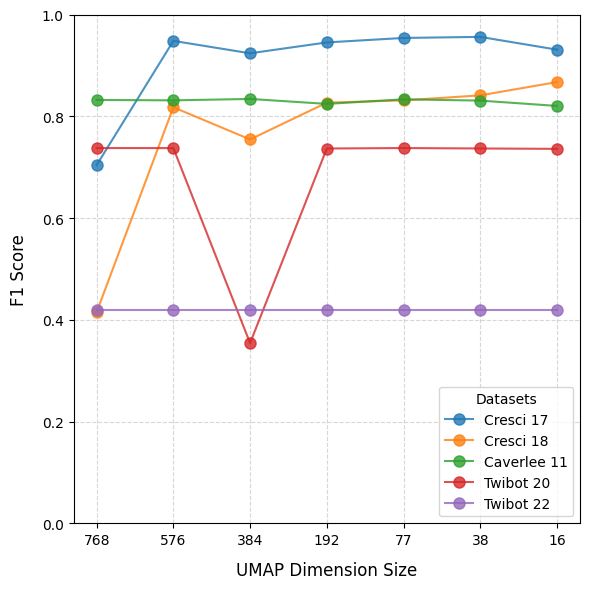

In [7]:
# creating the plot for the results
cresci17 = [0.7039437104254905,0.948171327079052,0.9237607911025848,0.9451386880406405,0.9539306390912481,0.956010997748841,0.9309312505233339]
cresci18 = [0.4150857142857143,0.8176845850703491,0.754483644711059,0.8268118364245585,0.8312218493226249,0.8410936461225946,0.8672311597178157]
caverlee11 = [0.8320938909414468,0.8312964431227287,0.8340495819884941,0.8243410762939581,0.8332980262431264,0.8308179274622802,0.8203217098864124]
twibot20 = [0.7375597133757962,0.7374944004778259,0.35426997245179065,0.7366694990116067,0.7375597133757962,0.7367342384365202,0.7359711640861801]
twibot22 = [0.418751652924987,0.418751652924987,0.418751652924987,0.418751652924987,0.418751652924987,0.418751652924987,0.418751652924987]


configurations = ["768", "576", "384", "192", "77", "38", "16"]
datasets_values = {
    "Cresci 17": cresci17,
    "Cresci 18": cresci18,
    "Caverlee 11": caverlee11,
    "Twibot 20": twibot20,
    "Twibot 22": twibot22,
}

# 3. Create the plot
plt.figure(figsize=(6, 6))

# Loop through the dictionary to plot each dataset
for dataset_name, values in datasets_values.items():
    # Use standard markers (dots). Matplotlib handles changing the colors automatically.
    plt.plot(configurations, values, marker="o", markersize=8 ,label=dataset_name, alpha=0.8)

# 4. Customize labels and layout
plt.xlabel("UMAP Dimension Size", fontsize=12, labelpad=10)
plt.ylabel("F1 Score", fontsize=12, labelpad=10)
plt.ylim(0, 1)
#plt.title("F1 Score across different datasets & UMAP dimension sizes", fontsize=14, pad=15)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Datasets", loc='lower right')

plt.tight_layout()
plt.show()